# Module 4: Feature Importance and Selection

**Workshop Track:** 200-Level  
**Prerequisites:** Modules 1, 2, and 3 complete

---

In Module 3, we built an enriched credit risk model using data from four tables: borrower demographics, financial snapshots, credit assessments, and payment history. By the end of it we had 22 features going into the model and a meaningfully better AUC than the four-feature baseline from Module 1.

But a good AUC only tells you *that* the model works. It does not tell you *which features* the model leaned on. Are the credit assessment scores carrying their weight, or is it really the financial features doing the work? Could you drop a third of the columns and keep similar accuracy?

This module is about ranking features by importance and using those rankings to make concrete decisions about your feature set. We will use NEXUS's `get_feature_importance()` to produce global importance scores, visualize them, and run a real feature-selection experiment: trim the bottom of the importance ranking and measure what happens to AUC.

Along the way, we will introduce the async pattern for the first time. Importance computation can take a while on large datasets, so NEXUS gives you both a synchronous and async path. Both are worth knowing.

## Learning Objectives

By the end of this notebook you will:

- Use `clf.get_feature_importance(X)` to rank features by importance for a trained model
- Visualize **global feature importance** across feature groups (borrower / financial / assessment / payment)
- Plot the **cumulative importance curve** to see how concentrated the model's signal is
- Use the async pattern: `submit_feature_importance_task()` and `poll_feature_importance_result()`
- Run a feature-selection experiment: trim the feature set using importance rankings and measure the impact on holdout AUC
- Pick a `TOP_FEATURES` set to carry forward into Module 5

---

## Setup

We need two things from Module 3 to continue: the enriched feature frame and the `ENRICHED_MODEL_ID`. The model id is retrieved automatically from the workshop state file (`_workshop_state.json`) on your Google Drive, written by the previous module — no manual copy-paste needed.

If the retrieval fails (e.g., you skipped Module 3 or the Drive mount), the cell will ask you to paste the `ENRICHED_MODEL_ID` printed at the end of Module 3. You can also look up your models manually with `client.models.list()`.

In [ ]:
# ============================================================================
# Workshop bootstrap — run this first. Safe to re-run. Identical in every module.
#
# In Google Colab, add two secrets via the key icon in the left sidebar
# (toggle "Notebook access" on for each):
#   • FUNDAMENTAL_API_KEY            — your NEXUS API key (ak_...)
#   • CLOUDSMITH_FUNDAMENTAL_TOKEN   — token to install the Fundamental SDK
#
# Each Colab notebook runs in its own fresh VM, so the modules share state
# (model IDs, feature lists) through a small JSON file on your Google Drive.
# This cell asks to mount Drive — approve the popup. If you decline, later
# modules will ask you to paste the values printed by earlier ones instead.
# See README.md for details.
# ============================================================================
import os, sys, json, subprocess
from pathlib import Path

# TODO at go-live: switch REPO to "Fundamental-Technologies/introduction-to-nexus"
REPO = "jawhnycooke/nexus_onboarding_workshop"

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# --- Dataset -----------------------------------------------------------------
# In Colab we sparse-fetch ONLY the dataset folder; the notebook itself is
# loaded straight from GitHub by Colab, so nothing else is needed on disk.
if IN_COLAB:
    _data_repo = Path("/content/workshop_data")
    DATASET_DIR = _data_repo / "dataset"
    if not DATASET_DIR.is_dir():
        print("Fetching the workshop dataset…")
        subprocess.run(["git", "clone", "--quiet", "--depth", "1", "--filter=blob:none",
                        "--sparse", f"https://github.com/{REPO}.git", str(_data_repo)],
                       check=True)
        subprocess.run(["git", "-C", str(_data_repo), "sparse-checkout", "set", "dataset"],
                       check=True)
    WORKSHOP_ROOT = Path("/content")
else:
    # Locally the notebooks live in workshop_colab/ inside the cloned repo,
    # and the dataset sits at the repo root.
    _here = Path.cwd().resolve()
    _repo_root = next((p for p in [_here, *_here.parents]
                       if (p / "workshop_colab").is_dir() and (p / "dataset").is_dir()), None)
    if _repo_root is None:
        raise RuntimeError(
            "Could not locate the repository root. Launch Jupyter from inside the "
            "cloned repository so the dataset/ folder can be found."
        )
    DATASET_DIR = _repo_root / "dataset"
    WORKSHOP_ROOT = _repo_root / "workshop_colab"

os.chdir(WORKSHOP_ROOT)

# --- Cross-module state ------------------------------------------------------
# Model IDs and the selected feature list pass between modules through one JSON
# file. In Colab it lives on your Google Drive so it survives across notebooks.
_DRIVE_MOUNTED = False
if IN_COLAB:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        _state_dir = Path("/content/drive/MyDrive/nexus_workshop")
        _state_dir.mkdir(parents=True, exist_ok=True)
        STATE_FILE = _state_dir / "_workshop_state.json"
        _DRIVE_MOUNTED = True
    except Exception as _e:
        print(f"Google Drive not mounted ({_e}).")
        print("State will NOT persist between notebooks — later modules will ask "
              "you to paste the values printed by earlier ones.")
        STATE_FILE = Path("/content/_workshop_state.json")
else:
    STATE_FILE = WORKSHOP_ROOT / "_workshop_state.json"


def save_state(key, value):
    state = json.loads(STATE_FILE.read_text()) if STATE_FILE.exists() else {}
    state[key] = value
    STATE_FILE.write_text(json.dumps(state, indent=2))
    print(f"Saved '{key}' = {value!r}")
    if IN_COLAB and not _DRIVE_MOUNTED:
        print("  (Drive is not mounted — copy this value; the next module will ask for it.)")


def load_state(key, default=None):
    if STATE_FILE.exists():
        return json.loads(STATE_FILE.read_text()).get(key, default)
    return default


def require_state(key, produced_by):
    val = load_state(key)
    if val is None:
        print(f"'{key}' was not found in the workshop state file ({STATE_FILE}).")
        print(f"It is produced by {produced_by}. If you ran that module without "
              "mounting Drive, paste the value it printed.")
        val = input(f"Paste {key} (or press Enter to abort): ").strip().strip("'\"")
        if not val:
            raise RuntimeError(
                f"'{key}' unavailable. Run {produced_by} first (approving the Drive "
                "mount), or re-run this cell and paste the printed value. See README.md."
            )
        save_state(key, val)
    return val


def _get_secret(name, required=True):
    val = os.getenv(name)
    if not val and IN_COLAB:
        try:
            from google.colab import userdata
            val = userdata.get(name)
        except Exception:
            val = None
    if required and not val:
        raise RuntimeError(
            f"Missing secret '{name}'.\n"
            "  • In Colab: open the key icon (Secrets) in the left sidebar, add a "
            f"secret named '{name}', and turn on 'Notebook access'.\n"
            f"  • Locally: export {name} in your shell before launching Jupyter.\n"
            "See README.md for details."
        )
    return val


# --- SDK install (Colab only; locally the SDK is installed during setup).
# Colab already ships pandas, numpy, scikit-learn, matplotlib and xgboost,
# so the Fundamental SDK is the only package to install.
try:
    import fundamental  # noqa: F401
except ImportError:
    if not IN_COLAB:
        raise RuntimeError(
            "Fundamental SDK not found. Install it locally (see README.md) before running."
        )
    _token = _get_secret("CLOUDSMITH_FUNDAMENTAL_TOKEN")
    print("Installing the Fundamental SDK…")
    _index = f"https://dl.cloudsmith.io/{_token}/fundamental/fundamental-client/python/simple/"
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "fundamental-client==0.10.0", "--extra-index-url", _index], check=True)

# --- Authentication ---
FUNDAMENTAL_API_KEY = _get_secret("FUNDAMENTAL_API_KEY")
os.environ["FUNDAMENTAL_API_KEY"] = FUNDAMENTAL_API_KEY

from fundamental import Fundamental, NEXUSClassifier, NEXUSRegressor, set_client
client = Fundamental()
set_client(client)

print(f"Workshop ready. Dataset: {DATASET_DIR}")
print(f"State file: {STATE_FILE}"
      + ("" if _DRIVE_MOUNTED or not IN_COLAB else "  (not persistent — Drive not mounted)"))
print(f"API key prefix: {FUNDAMENTAL_API_KEY[:8]}…")


In [2]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import roc_auc_score

In [3]:
# Retrieve your ENRICHED_MODEL_ID from Module 3 (stored automatically if you ran Module 3)
# Attempt to load it now; we verify the id is actually live (and re-fit if not)
# once the feature frame is rebuilt in Part 1.
nexus = NEXUSClassifier(mode="quality")
_model_loaded = False
try:
    ENRICHED_MODEL_ID = require_state("ENRICHED_MODEL_ID", "module_03")
    nexus.load_model(ENRICHED_MODEL_ID)
    _model_loaded = True
    print(f"Model loaded: {ENRICHED_MODEL_ID}")
except Exception:
    print("Stored model id missing/stale — will fit a fresh model in Part 1.")

Model loaded: 2b084e09-c77a-4ac6-848f-c59230be3593


---

## Part 1: Rebuild the Enriched Feature Frame

We need to reconstruct the same feature frame we trained on in Module 3. The trained model was registered against a specific column schema (the same categorical and numeric columns, including the derived tenure feature), and `get_feature_importance()` requires we pass data with the same schema. Re-applying the M03 preprocessing pipeline is the simplest way to guarantee parity. NEXUS accepts raw categorical columns natively, so we pass the categoricals as-is — and because NEXUS does not accept datetime columns, the account-open date is converted to the numeric `account_tenure_days` feature, exactly as in Module 3.

In [4]:
DATA_DIR = DATASET_DIR / "credit_risk"

# Load all source tables
train_raw    = pd.read_csv(DATA_DIR / "borrowers_train.csv")
holdout_raw  = pd.read_csv(DATA_DIR / "borrowers_holdout.csv")
snapshots    = pd.read_csv(DATA_DIR / "financial_snapshots.csv", parse_dates=["snapshot_date"])
assessments  = pd.read_csv(DATA_DIR / "credit_assessments.csv", parse_dates=["assessment_date"])
payments     = pd.read_csv(DATA_DIR / "payment_events.csv", parse_dates=["payment_date"])

print(f"Source tables loaded.")
print(f"  borrowers_train:     {len(train_raw):,} rows")
print(f"  financial_snapshots: {len(snapshots):,} rows")
print(f"  credit_assessments:  {len(assessments):,} rows")
print(f"  payment_events:      {len(payments):,} rows")

Source tables loaded.
  borrowers_train:     4,591 rows
  financial_snapshots: 14,599 rows
  credit_assessments:  24,607 rows
  payment_events:      44,750 rows


In [5]:
# Prep the join tables (same logic as Module 3)
snapshots_latest = (
    snapshots
    .sort_values("snapshot_date", ascending=False)
    .drop_duplicates(subset="borrower_id", keep="first")
    [["borrower_id", "monthly_income_usd", "income_growth_pct",
      "collateral_score", "secondary_income_flag"]]
)

assessments_latest = (
    assessments
    .sort_values("assessment_date", ascending=False)
    .drop_duplicates(subset="borrower_id", keep="first")
    [["borrower_id", "creditworthiness_rating", "payment_behavior_score",
      "financial_stability_score", "lender_relationship_score",
      "credit_engagement_score", "debt_service_score"]]
)

payment_agg = (
    payments
    .groupby("borrower_id")
    .agg(
        total_payments=("payment_id", "count"),
        on_time_rate=("on_time", lambda x: (x == "Yes").mean()),
        avg_payment_usd=("amount_usd", "mean"),
    )
    .reset_index()
)

def enrich(df):
    out = df.copy()
    out = out.merge(snapshots_latest, on="borrower_id", how="left")
    out = out.merge(assessments_latest, on="borrower_id", how="left")
    out = out.merge(payment_agg, on="borrower_id", how="left")
    return out

train_enriched   = enrich(train_raw)
holdout_enriched = enrich(holdout_raw)

drop_cols    = ["borrower_id", "first_name", "last_name", "default_flag"]
feature_cols = [c for c in train_enriched.columns if c not in drop_cols]

# Same preprocessing as Module 3. Categoricals pass through unchanged;
# the date becomes the numeric tenure feature.
def add_account_tenure(df, date_col="account_open_date", ref_date="2026-01-01"):
    """Convert the account-open date into a numeric tenure feature.

    NEXUS accepts numeric, boolean, string, and categorical columns — but not
    datetime columns. So instead of parsing the date, we derive an explicit
    numeric feature: the account's age in days at a fixed reference date.
    (A fixed reference keeps the feature stable across runs.)
    """
    out = df.copy()
    out["account_tenure_days"] = (
        pd.Timestamp(ref_date) - pd.to_datetime(out[date_col])
    ).dt.days
    return out.drop(columns=[date_col])


X_train = add_account_tenure(train_enriched[feature_cols])
X_holdout = add_account_tenure(holdout_enriched[feature_cols])

y_train = train_enriched["default_flag"]
y_holdout = holdout_enriched["default_flag"]

print(f"Feature frame: {X_train.shape[0]:,} rows x {X_train.shape[1]} features")
print(f"Features: {list(X_train.columns)}")

# Now that the feature frame exists, confirm the loaded model is actually live.
# A stored id can be stale/expired; probe it with a single row, and fall back to
# re-fitting a fresh enriched model on this module's own training data if needed.
try:
    if not _model_loaded:
        raise RuntimeError("model was not loaded from the stored id")
    _ = nexus.predict_proba(X_holdout.head(1))  # probe that the id is live
except Exception:
    print("Stored model id missing/stale — fitting a fresh model.")
    nexus = NEXUSClassifier(mode="quality")
    nexus.fit(X_train, y_train)
    ENRICHED_MODEL_ID = nexus.trained_model_id_
    print(f"Fresh model fitted: {ENRICHED_MODEL_ID}")

Feature frame: 4,591 rows x 22 features
Features: ['age', 'gender', 'marital_status', 'distance_from_branch_miles', 'education_level', 'occupation_sector', 'num_previous_lenders', 'total_employment_years', 'monthly_income_usd', 'income_growth_pct', 'collateral_score', 'secondary_income_flag', 'creditworthiness_rating', 'payment_behavior_score', 'financial_stability_score', 'lender_relationship_score', 'credit_engagement_score', 'debt_service_score', 'total_payments', 'on_time_rate', 'avg_payment_usd', 'account_tenure_days']


---

## Part 2: Global Feature Importance

### The get_feature_importance() Call

`get_feature_importance(X)` returns a flat numpy array of importance scores — one score per input feature, in the same column order as `X`. Pair it with `X.columns` and you have a ready-made importance ranking.

The call blocks until the computation completes — expect a minute or two on this dataset. For larger or more time-sensitive workloads, the async path (`submit_feature_importance_task` / `poll_feature_importance_result`) is shown in Part 4.

One thing to hold onto: these scores are **global** — one number per feature, summarizing the model's reliance across the whole dataset. They are not per-borrower explanations, and a high score means "the model leans on this," not "this causes default."

In [6]:
print("Computing feature importance (synchronous)...")
t0 = time.time()

importance_array = nexus.get_feature_importance(X_holdout)

elapsed = time.time() - t0
print(f"Done in {elapsed:.1f}s")
print(f"Shape: {importance_array.shape}")

Computing feature importance (synchronous)...


Done in 111.0s
Shape: (22,)


### Building the Importance DataFrame

The flat ndarray is fine for plotting, but for ranking and inspection it's easier to work with as a DataFrame paired with feature names. We also add an `importance_pct` column — this is a presentational normalization we apply ourselves (each score divided by the sum of the scores), not a property the SDK returns or guarantees. It just rescales the raw scores to 0-100 so the ranking is easier to read and chart, and lets us talk about a feature as a share of the ranked total.

In [7]:
# Pair the importance scores with column names and rank
importance_df = pd.DataFrame({
    "feature": X_holdout.columns,
    "importance": importance_array,
}).sort_values("importance", ascending=False).reset_index(drop=True)

# Presentational only: rescale each score to a 0-100 share of the
# ranked total for readability. This is our own normalization, not
# something the SDK returns.
importance_df["importance_pct"] = (
    importance_df["importance"] / importance_df["importance"].sum() * 100
).round(2)

print(importance_df.to_string(index=False))

                   feature  importance  importance_pct
        monthly_income_usd    0.241462           24.15
           avg_payment_usd    0.222600           22.26
    total_employment_years    0.104256           10.43
                       age    0.070572            7.06
       account_tenure_days    0.057218            5.72
     secondary_income_flag    0.054520            5.45
            marital_status    0.041748            4.17
distance_from_branch_miles    0.030898            3.09
          collateral_score    0.028824            2.88
         occupation_sector    0.027425            2.74
 financial_stability_score    0.020426            2.04
      num_previous_lenders    0.017651            1.77
    payment_behavior_score    0.014047            1.40
   credit_engagement_score    0.012571            1.26
         income_growth_pct    0.011689            1.17
           education_level    0.009817            0.98
        debt_service_score    0.009382            0.94
   creditw

---

## Part 3: Visualizing Global Importance

### Feature Groups

Before plotting, let's tag each feature with the source table it came from. This will let us color-code the chart and see whether credit assessments, payment behavior, or raw borrower demographics are carrying the most predictive weight.

In [8]:
# Map features to their source groups
group_map = {
    # Borrower table (base)
    "age":                        "Borrower",
    "gender":                     "Borrower",
    "marital_status":             "Borrower",
    "education_level":            "Borrower",
    "occupation_sector":          "Borrower",
    "distance_from_branch_miles": "Borrower",
    "num_previous_lenders":       "Borrower",
    "total_employment_years":     "Borrower",
    "account_tenure_days":        "Borrower",
    # Financial snapshots
    "monthly_income_usd":         "Financial",
    "income_growth_pct":          "Financial",
    "collateral_score":           "Financial",
    "secondary_income_flag":      "Financial",
    # Credit assessments
    "creditworthiness_rating":    "Assessment",
    "payment_behavior_score":     "Assessment",
    "financial_stability_score":  "Assessment",
    "lender_relationship_score":  "Assessment",
    "credit_engagement_score":    "Assessment",
    "debt_service_score":         "Assessment",
    # Payment events
    "total_payments":             "Payment",
    "on_time_rate":               "Payment",
    "avg_payment_usd":            "Payment",
}

importance_df["group"] = importance_df["feature"].map(group_map).fillna("Other")

# Group summary
group_summary = (
    importance_df.groupby("group")["importance_pct"]
    .sum()
    .sort_values(ascending=False)
    .round(2)
)
print("Importance by source group (% of total):")
print(group_summary.to_string())

Importance by source group (% of total):
group
Borrower      36.25
Financial     33.65
Payment       23.04
Assessment     7.05


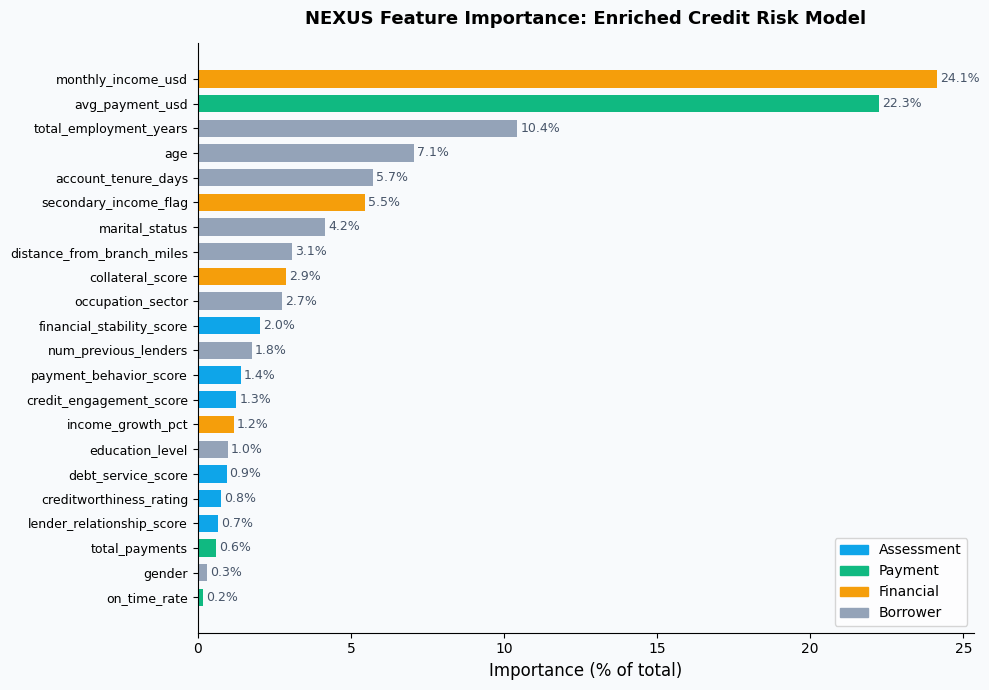

Chart saved.


In [9]:
# Color palette by group
group_colors = {
    "Assessment": "#0EA5E9",   # sky blue
    "Payment":    "#10B981",   # emerald
    "Financial":  "#F59E0B",   # amber
    "Borrower":   "#94A3B8",   # slate
    "Other":      "#CBD5E1",
}

bar_colors = importance_df["group"].map(group_colors)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    importance_df["feature"][::-1],
    importance_df["importance_pct"][::-1],
    color=bar_colors[::-1],
    edgecolor="none",
    height=0.7,
)

# Add value labels
for bar, val in zip(bars, importance_df["importance_pct"][::-1]):
    ax.text(
        bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%", va="center", ha="left", fontsize=9, color="#475569"
    )

# Legend
legend_patches = [
    mpatches.Patch(color=color, label=group)
    for group, color in group_colors.items()
    if group in importance_df["group"].values
]
ax.legend(handles=legend_patches, loc="lower right", fontsize=10, framealpha=0.8)

ax.set_xlabel("Importance (% of total)", fontsize=12)
ax.set_title("NEXUS Feature Importance: Enriched Credit Risk Model",
             fontsize=13, fontweight="bold", pad=14)
ax.set_facecolor("#F8FAFC")
fig.patch.set_facecolor("#F8FAFC")
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="y", labelsize=9)

plt.tight_layout()
plt.savefig("module_04_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

### Reading the Chart

The percentages below are the normalized `importance_pct` share we computed above — a presentational rescaling of the raw scores, not a guaranteed SDK output. A few things to look for:

**Borrower demographics carry significant weight as a group.** Features from the borrower table — including `age`, `total_employment_years`, `account_tenure_days`, and `occupation_sector` — collectively account for a large share of the ranked total. The base borrower profile captures long-term stability signals that are hard to replicate from other sources.

**Financial features punch above their weight.** `monthly_income_usd` alone is typically among the top-ranked features, and together with `secondary_income_flag`, `collateral_score`, and `income_growth_pct`, the financial group accounts for a substantial share despite having only four columns.

**Payment behavior is dominated by a single feature.** `avg_payment_usd` typically ranks near the top, but `on_time_rate` and `total_payments` are usually further down. The payment group's importance is concentrated, not spread evenly.

**Credit assessment scores often rank lower than expected.** The six analyst-scored dimensions (`creditworthiness_rating`, `debt_service_score`, etc.) collectively account for a smaller fraction of the ranked total than you might assume. Structured human judgment does not always outperform raw behavioral and demographic data — an important lesson for feature engineering.

**The long tail is real.** The bottom features share only a small fraction of the ranked total. Removing them is unlikely to hurt performance and will simplify everything downstream — that's exactly what we test in Part 5.

---

## Part 4: The Async Pattern (First Look)

### Why Async Exists

The synchronous `get_feature_importance()` call works well when the computation finishes in a few minutes. But on large datasets, or when NEXUS is handling high load, the call can take significantly longer.

Blocking your Python process for several minutes is not a great production pattern. You cannot do anything else while you wait, and if the connection drops, you lose the result entirely.

The async pattern solves this. Think of it like dropping off a document at a print shop versus waiting at the counter: you submit the job, get a receipt (a task ID), do other things, and come back to check when it is done. The computation runs on Fundamental's infrastructure; your process is free.

This is the same pattern we will use extensively in Modules 5 and 6 for training and prediction. Feature importance is a good place to see it for the first time because the concept is simple.

### Step 1: Submit the Task

In [10]:
# Submit the feature-importance job without blocking
task_id = nexus.submit_feature_importance_task(X_holdout)

print(f"Task submitted. ID: {task_id}")
print()
print("You can save this task ID and poll for results later.")
print("Your Python process is free to do other work while this runs.")

Task submitted. ID: 5f367274fe4ea875a372536264e12b2c

You can save this task ID and poll for results later.
Your Python process is free to do other work while this runs.


### Step 2: Poll for the Result

`poll_feature_importance_result()` returns the importance ndarray if the job is done, or `None` if it is still running. We loop with a sleep interval until we get a result.

**In a real pipeline**, you would not use a blocking loop like this. You would save the task ID to a database, check it from a scheduled job, or use a webhook. The loop below is for demonstration purposes in a notebook context.

In [11]:
print(f"Polling task {task_id}...")

POLL_INTERVAL_SECONDS = 15
async_importance = None

while async_importance is None:
    async_importance = nexus.poll_feature_importance_result(task_id)
    if async_importance is None:
        print(f"  Still running... checking again in {POLL_INTERVAL_SECONDS}s")
        time.sleep(POLL_INTERVAL_SECONDS)

print(f"\nTask complete. Result shape: {async_importance.shape}")

Polling task 5f367274fe4ea875a372536264e12b2c...
  Still running... checking again in 15s


  Still running... checking again in 15s


  Still running... checking again in 15s


  Still running... checking again in 15s


  Still running... checking again in 15s


  Still running... checking again in 15s


  Still running... checking again in 15s


  Still running... checking again in 15s



Task complete. Result shape: (22,)


### Check the Async Result

The async path returns the same kind of result as the synchronous call: a flat ndarray with one score per feature, in the same shape and column order. The exact scores can differ slightly from run to run, so don't expect the two arrays to match element-for-element. Let's confirm the shape and look at how far the values drift.

In [12]:
# Compare sync vs async importance — both arrays are the same shape, same column order
assert importance_array.shape == async_importance.shape
print(f"Both arrays have shape {async_importance.shape}, same column order.")

max_delta = np.max(np.abs(importance_array - async_importance))
print(f"Max absolute difference between sync and async scores: {max_delta:.6f}")
print("Same kind of result (a flat ndarray); exact scores may drift slightly run to run.")

Both arrays have shape (22,), same column order.
Max absolute difference between sync and async scores: 0.000000
Same kind of result (a flat ndarray); exact scores may drift slightly run to run.


---

## Part 5: Feature Selection Experiment

### The Core Question

Now that we know which features matter, let's test the obvious hypothesis: can we drop the bottom half of the importance ranking and keep roughly the same AUC?

This is not a trivial question. Importance scores tell you how much each feature contributed to the model you already trained. They do not directly tell you what happens to a freshly-trained model without those features. The relationships between features are nonlinear, and dropping a low-importance feature could, in principle, affect how the model uses other features.

The only way to find out is to run the experiment.

A working heuristic for the cutoff: under about 0.005 AUC drop is usually safe to ship; between 0.005 and 0.01, get stakeholder buy-in; beyond that you are trading real signal for a smaller frame. Domains differ — fraud teams run stricter, marketing teams looser.

In [13]:
# Establish baseline AUC on holdout (full enriched model)
proba_full    = nexus.predict_proba(X_holdout)
auc_full      = roc_auc_score(y_holdout, proba_full[:, 1])
print(f"Baseline AUC (all {len(feature_cols)} features): {auc_full:.4f}")

Baseline AUC (all 22 features): 0.9378


In [14]:
# Select the top features by importance
# We will test three thresholds: top 15, top 10, and top 5
thresholds = [15, 10, 5]

results = [{"n_features": len(X_train.columns), "auc": auc_full, "label": "Full set (baseline)"}]

for n in thresholds:
    top_features = importance_df.head(n)["feature"].tolist()

    X_train_slim   = X_train[top_features]
    X_holdout_slim = X_holdout[top_features]

    nexus_slim = NEXUSClassifier(mode="quality")
    nexus_slim.fit(X_train_slim, y_train)

    proba_slim = nexus_slim.predict_proba(X_holdout_slim)
    auc_slim   = roc_auc_score(y_holdout, proba_slim[:, 1])

    results.append({"n_features": n, "auc": auc_slim, "label": f"Top {n} features"})
    print(f"Top {n:2d} features | AUC: {auc_slim:.4f} | delta: {auc_slim - auc_full:+.4f}")

print(f"\nBaseline: {len(X_train.columns)} features | AUC: {auc_full:.4f}")

Top 15 features | AUC: 0.9433 | delta: +0.0055


Top 10 features | AUC: 0.9217 | delta: -0.0161


Top  5 features | AUC: 0.7822 | delta: -0.1556

Baseline: 22 features | AUC: 0.9378


### Visualizing the Feature-Count Trade-off

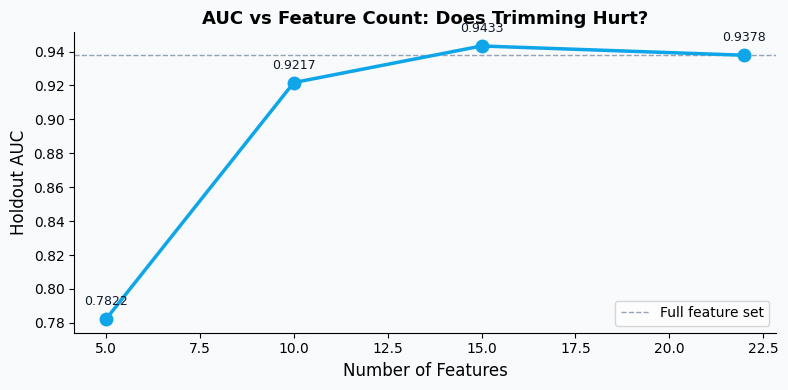

Chart saved.


In [15]:
results_df = pd.DataFrame(results).sort_values("n_features")

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    results_df["n_features"],
    results_df["auc"],
    marker="o", color="#0EA5E9", linewidth=2.5, markersize=9, zorder=3
)

# Annotate each point
for _, row in results_df.iterrows():
    ax.annotate(
        f"{row['auc']:.4f}",
        (row["n_features"], row["auc"]),
        textcoords="offset points", xytext=(0, 10),
        ha="center", fontsize=9, color="#0F172A"
    )

# Baseline reference line
ax.axhline(auc_full, color="#94A3B8", linewidth=1, linestyle="--", label="Full feature set")

ax.set_xlabel("Number of Features", fontsize=12)
ax.set_ylabel("Holdout AUC", fontsize=12)
ax.set_title("AUC vs Feature Count: Does Trimming Hurt?", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.set_facecolor("#F8FAFC")
fig.patch.set_facecolor("#F8FAFC")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("module_04_feature_selection.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

### Reading the Results

The chart typically tells a story that looks like this: dropping the bottom few features costs almost nothing in AUC, but cutting more aggressively starts to hurt. In our case, the top 15 features (about two-thirds of the full set) lost less than 0.001 in AUC, while cutting to 10 (about half) cost 0.025 — still usable, but a real trade-off. Going down to 5 features caused a dramatic collapse. The sweet spot for this dataset is around 15 features.

A few principles to take away from this experiment:

**Importance scores are a starting point, not a verdict.** Rank the features, test the cuts, and let the holdout AUC be the final arbiter. Never drop features based on importance alone without empirically verifying the impact.

**Low-importance features are not always safe to drop.** A feature can score low in importance and still contribute to model calibration or stability. Run the experiment before committing.

**Trimming has real operational value.** A model with 12 features instead of 25 requires less data to collect at inference time, is easier to monitor, and is simpler to explain to stakeholders. If the AUC difference is less than 0.005, the leaner model is almost always the right choice in production.

---

## Bonus: The Importance Waterfall

A cumulative importance curve is a useful diagnostic for understanding how concentrated your model's signal is. If the top 3 features account for 70% of importance, your model has a very narrow base — which can be a fragility risk if those data sources change.

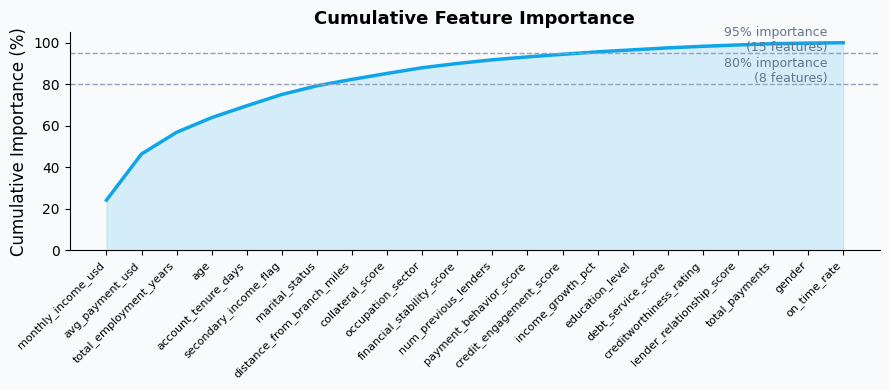

Cumulative importance chart saved.


In [16]:
cumulative_importance = importance_df["importance_pct"].cumsum()

fig, ax = plt.subplots(figsize=(9, 4))

ax.fill_between(
    range(1, len(X_train.columns) + 1),
    cumulative_importance,
    color="#0EA5E9", alpha=0.15
)
ax.plot(
    range(1, len(X_train.columns) + 1),
    cumulative_importance,
    color="#0EA5E9", linewidth=2.5
)

# 80% and 95% reference lines
for threshold in [80, 95]:
    n_at_threshold = (cumulative_importance >= threshold).idxmax() + 1
    ax.axhline(threshold, color="#94A3B8", linewidth=1, linestyle="--")
    ax.text(
        len(X_train.columns) * 0.98, threshold + 1,
        f"{threshold}% importance\n({n_at_threshold} features)",
        ha="right", fontsize=9, color="#64748B"
    )

ax.set_xticks(range(1, len(X_train.columns) + 1))
ax.set_xticklabels(
    importance_df["feature"].tolist(),
    rotation=45, ha="right", fontsize=8
)
ax.set_ylabel("Cumulative Importance (%)", fontsize=12)
ax.set_title("Cumulative Feature Importance", fontsize=13, fontweight="bold")
ax.set_ylim(0, 105)
ax.set_facecolor("#F8FAFC")
fig.patch.set_facecolor("#F8FAFC")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("module_04_cumulative_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Cumulative importance chart saved.")

---

## Save Your Results

Save the top features list -- you will use it in Module 5 when we introduce full async training and prediction workflows.

In [17]:
# Recommended top-feature set for downstream modules
# Adjust the cutoff based on your experimental results above
TOP_N = 15
TOP_FEATURES = importance_df.head(TOP_N)["feature"].tolist()

# Store for Modules 5-8
save_state("TOP_FEATURES", TOP_FEATURES)
save_state("ENRICHED_MODEL_ID", ENRICHED_MODEL_ID)

print(f"=== Save These Results ===")
print(f"Enriched model ID:  {ENRICHED_MODEL_ID}")
print(f"Top {TOP_N} features: {TOP_FEATURES}")
print()
print("Importance summary:")
print(importance_df[["feature", "importance_pct", "group"]].to_string(index=False))

Saved 'TOP_FEATURES' to workshop state.
Saved 'ENRICHED_MODEL_ID' to workshop state.
=== Save These Results ===
Enriched model ID:  2b084e09-c77a-4ac6-848f-c59230be3593
Top 15 features: ['monthly_income_usd', 'avg_payment_usd', 'total_employment_years', 'age', 'account_tenure_days', 'secondary_income_flag', 'marital_status', 'distance_from_branch_miles', 'collateral_score', 'occupation_sector', 'financial_stability_score', 'num_previous_lenders', 'payment_behavior_score', 'credit_engagement_score', 'income_growth_pct']

Importance summary:
                   feature  importance_pct      group
        monthly_income_usd           24.15  Financial
           avg_payment_usd           22.26    Payment
    total_employment_years           10.43   Borrower
                       age            7.06   Borrower
       account_tenure_days            5.72   Borrower
     secondary_income_flag            5.45  Financial
            marital_status            4.17   Borrower
distance_from_branch_m

---

## Key Takeaways

**`get_feature_importance()` is the synchronous path.** Pass your input data, block until the call returns, and get back a flat ndarray of importance scores aligned to your column order. Best for interactive notebooks and quick analysis.

**`submit_feature_importance_task()` + `poll_feature_importance_result()` is the async path.** Submit to get a task ID immediately, poll periodically to check completion. Best for large datasets, production pipelines, and any context where you cannot afford a blocking wait.

**NEXUS feature importance is global.** `get_feature_importance()` returns one ranked score per feature — what the model relies on across the whole dataset. NEXUS does not expose per-prediction (local) explanations; there is no per-record "why this borrower" output from the model. For instance-level questions you would layer a separate explainability technique on top. Use global importance for model-level understanding, governance reviews, and feature selection.

**Importance scores inform feature selection, but do not dictate it.** Always validate cuts on a holdout set. The trim experiment you ran here should become a standard step in any NEXUS workflow before you finalize a feature set for production.

**The async pattern shows up everywhere.** The same submit/poll loop you used for importance in this module is the same pattern you will use for training and prediction in Modules 5 and 6. You have already seen the hardest part of it.

---

**What's Next — Module 5: Async Patterns**

Module 5 goes deep on the full async workflow: `submit_fit_task`, `poll_fit_result`, `submit_predict_task`, and `poll_predict_result`. We will build a real multi-step pipeline where training and prediction are both non-blocking, and walk through the patterns for handling partial failures mid-pipeline.